# 01 · Data Preprocessing
**C-MAPSS Turbofan Engine Degradation — FD001 & FD003**

> Covers raw loading → EDA → feature selection → RUL labelling → normalisation → sliding-window sequence creation → train / validation / test split → artefact saving.

---
## Section 1 · Project Setup

In [ ]:
# ── Google Drive mount (comment out if running locally) ──────────────────────
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')
else:
    print('Running locally — Drive mount skipped.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
# ── Install / upgrade packages if needed ─────────────────────────────────────
# Uncomment the line below when running in a fresh environment.
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# ── Standard imports ─────────────────────────────────────────────────────────
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print('All packages imported successfully.')

All packages imported successfully.


In [ ]:
# ── Folder paths ─────────────────────────────────────────────────────────────
# Adjust BASE_DATA_DIR to wherever you stored the C-MAPSS .txt files.
# Expected sub-structure:
#   <BASE_DATA_DIR>/
#       train_FD001.txt  test_FD001.txt  RUL_FD001.txt
#       train_FD003.txt  test_FD003.txt  RUL_FD003.txt

if IN_COLAB:
    BASE_DATA_DIR = '/content/drive/MyDrive/CMAPSSData'   # ← change as needed
else:
    BASE_DATA_DIR = './data/CMAPSSData'                    # ← change as needed

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ['FD001', 'FD003']

print(f'Data dir : {os.path.abspath(BASE_DATA_DIR)}')
print(f'Output dir: {os.path.abspath(OUTPUT_DIR)}')

Data dir : /content/drive/MyDrive/CMAPSSData
Output dir: /content/outputs


In [ ]:
# ── Random seed ───────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Random seed set to {RANDOM_SEED}.')

Random seed set to 42.


---
## Section 2 · Dataset Description

### Source
The **C-MAPSS** (Commercial Modular Aero-Propulsion System Simulation) dataset was published by NASA's Prognostics Center of Excellence and is widely used as the benchmark for Remaining Useful Life (RUL) prediction of turbofan engines. It can be downloaded from the [NASA Prognostics Data Repository](https://www.nasa.gov/content/prognostics-center-of-excellence-data-set-repository).

### Why FD001 and FD003?
The C-MAPSS dataset contains four sub-datasets (FD001–FD004). Following the experimental setup in:
> *Li, X., Ding, Q., & Sun, J.-Q. (2018). Remaining useful life estimation in prognostics using deep convolution neural networks. Reliability Engineering & System Safety, 172, 1–11.*  
> *(and related work published in Sensors)*

we focus on **FD001** (single operating condition, single fault mode — HPC degradation) and **FD003** (single operating condition, *two* fault modes — HPC + fan degradation). This pair lets us study how fault mode diversity affects model generalisation while keeping the operating regime constant.

### Row semantics
Each row represents **one operational cycle** of one engine.  
The engine runs from an initially healthy state until failure; cycles are numbered sequentially per engine starting at 1.

### Column layout

| Column | Description |
|--------|-------------|
| `unit_nr` | Engine (unit) identifier |
| `time_cycles` | Cycle counter for that engine (1 → failure) |
| `op_setting_1/2/3` | Three operational condition settings |
| `sensor_1` … `sensor_21` | 21 sensor measurements (temperatures, pressures, fan/core speeds, fuel flow, etc.) |

The raw files have **no header row** and space-delimited values. FD001 contains 100 training engines; FD003 contains 100 training engines.

---
## Section 3 · Load Raw Files

In [ ]:
# ── Column names ─────────────────────────────────────────────────────────────
SENSOR_COLS     = [f'sensor_{i}' for i in range(1, 22)]       # sensor_1 … sensor_21
OP_SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']
BASE_COLS       = ['unit_nr', 'time_cycles'] + OP_SETTING_COLS + SENSOR_COLS

print(f'Total named columns: {len(BASE_COLS)}')
print(BASE_COLS)

Total named columns: 26
['unit_nr', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
# ── Generic loader ────────────────────────────────────────────────────────────
def load_cmapss(filepath: str, col_names: list) -> pd.DataFrame:
    """Load a C-MAPSS space-delimited file and assign column names.
    Drops any trailing blank columns produced by trailing whitespace.
    """
    df = pd.read_csv(filepath, sep=r'\s+', header=None, engine='python')
    # Drop extra blank columns (the raw files sometimes end with a space)
    df.dropna(axis=1, how='all', inplace=True)
    df.columns = col_names[:df.shape[1]]
    return df


raw = {}   # will hold {'FD001': {'train': df, 'test': df, 'rul': series}, ...}

for ds in DATASETS:
    train_path = os.path.join(BASE_DATA_DIR, f'train_{ds}.txt')
    test_path  = os.path.join(BASE_DATA_DIR, f'test_{ds}.txt')
    rul_path   = os.path.join(BASE_DATA_DIR, f'RUL_{ds}.txt')

    df_train = load_cmapss(train_path, BASE_COLS)
    df_test  = load_cmapss(test_path,  BASE_COLS)
    df_rul   = pd.read_csv(rul_path, header=None, names=['rul_true'])

    raw[ds] = {'train': df_train, 'test': df_test, 'rul': df_rul}

    print(f'[{ds}]  train: {df_train.shape}  |  test: {df_test.shape}  |  RUL rows: {len(df_rul)}')

[FD001]  train: (20631, 26)  |  test: (13096, 26)  |  RUL rows: 100
[FD003]  train: (24720, 26)  |  test: (16596, 26)  |  RUL rows: 100


---
## Section 4 · Initial EDA

In [ ]:
# ── Basic statistics ──────────────────────────────────────────────────────────
for ds in DATASETS:
    df = raw[ds]['train']
    n_engines  = df['unit_nr'].nunique()
    min_cycles = df.groupby('unit_nr')['time_cycles'].max().min()
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().max()

    print(f'\n── {ds} training set ──')
    print(f'  Shape        : {df.shape}')
    print(f'  Engines      : {n_engines}')
    print(f'  Min life     : {min_cycles} cycles')
    print(f'  Max life     : {max_cycles} cycles')
    print(f'  Null values  : {df.isnull().sum().sum()}')
    print(f'  Duplicates   : {df.duplicated().sum()}')
    print(df.head(3).to_string())


── FD001 training set ──
  Shape        : (20631, 26)
  Engines      : 100
  Min life     : 128 cycles
  Max life     : 362 cycles
  Null values  : 0
  Duplicates   : 0
   unit_nr  time_cycles  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21
0        1            1       -0.0007       -0.0004         100.0    518.67    641.82   1589.70   1400.60     14.62     21.61    554.36   2388.06   9046.19        1.3      47.47     521.66    2388.02    8138.62     8.4195       0.03        392       2388      100.0      39.06    23.4190
1        1            2        0.0019       -0.0003         100.0    518.67    642.15   1591.82   1403.14     14.62     21.61    553.75   2388.04   9044.07        1.3      47.49     522.28    2388.07    8131.49     8.4318       0.03        392       2388

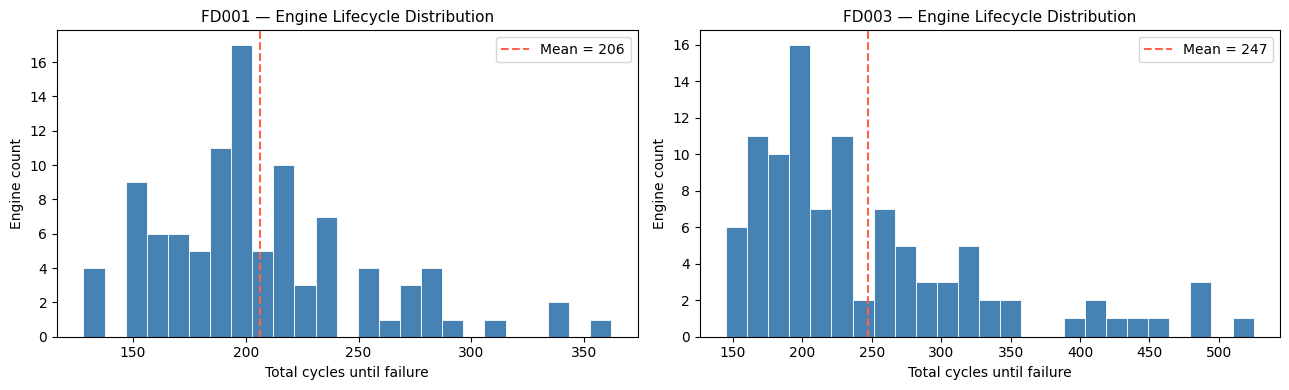

In [ ]:
# ── Engine lifecycle histogram ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, ds in zip(axes, DATASETS):
    lives = raw[ds]['train'].groupby('unit_nr')['time_cycles'].max()
    ax.hist(lives, bins=25, color='steelblue', edgecolor='white', linewidth=0.6)
    ax.set_title(f'{ds} — Engine Lifecycle Distribution', fontsize=11)
    ax.set_xlabel('Total cycles until failure')
    ax.set_ylabel('Engine count')
    ax.axvline(lives.mean(), color='tomato', linestyle='--', label=f'Mean = {lives.mean():.0f}')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_lifecycle_hist.png'), dpi=120)
plt.show()

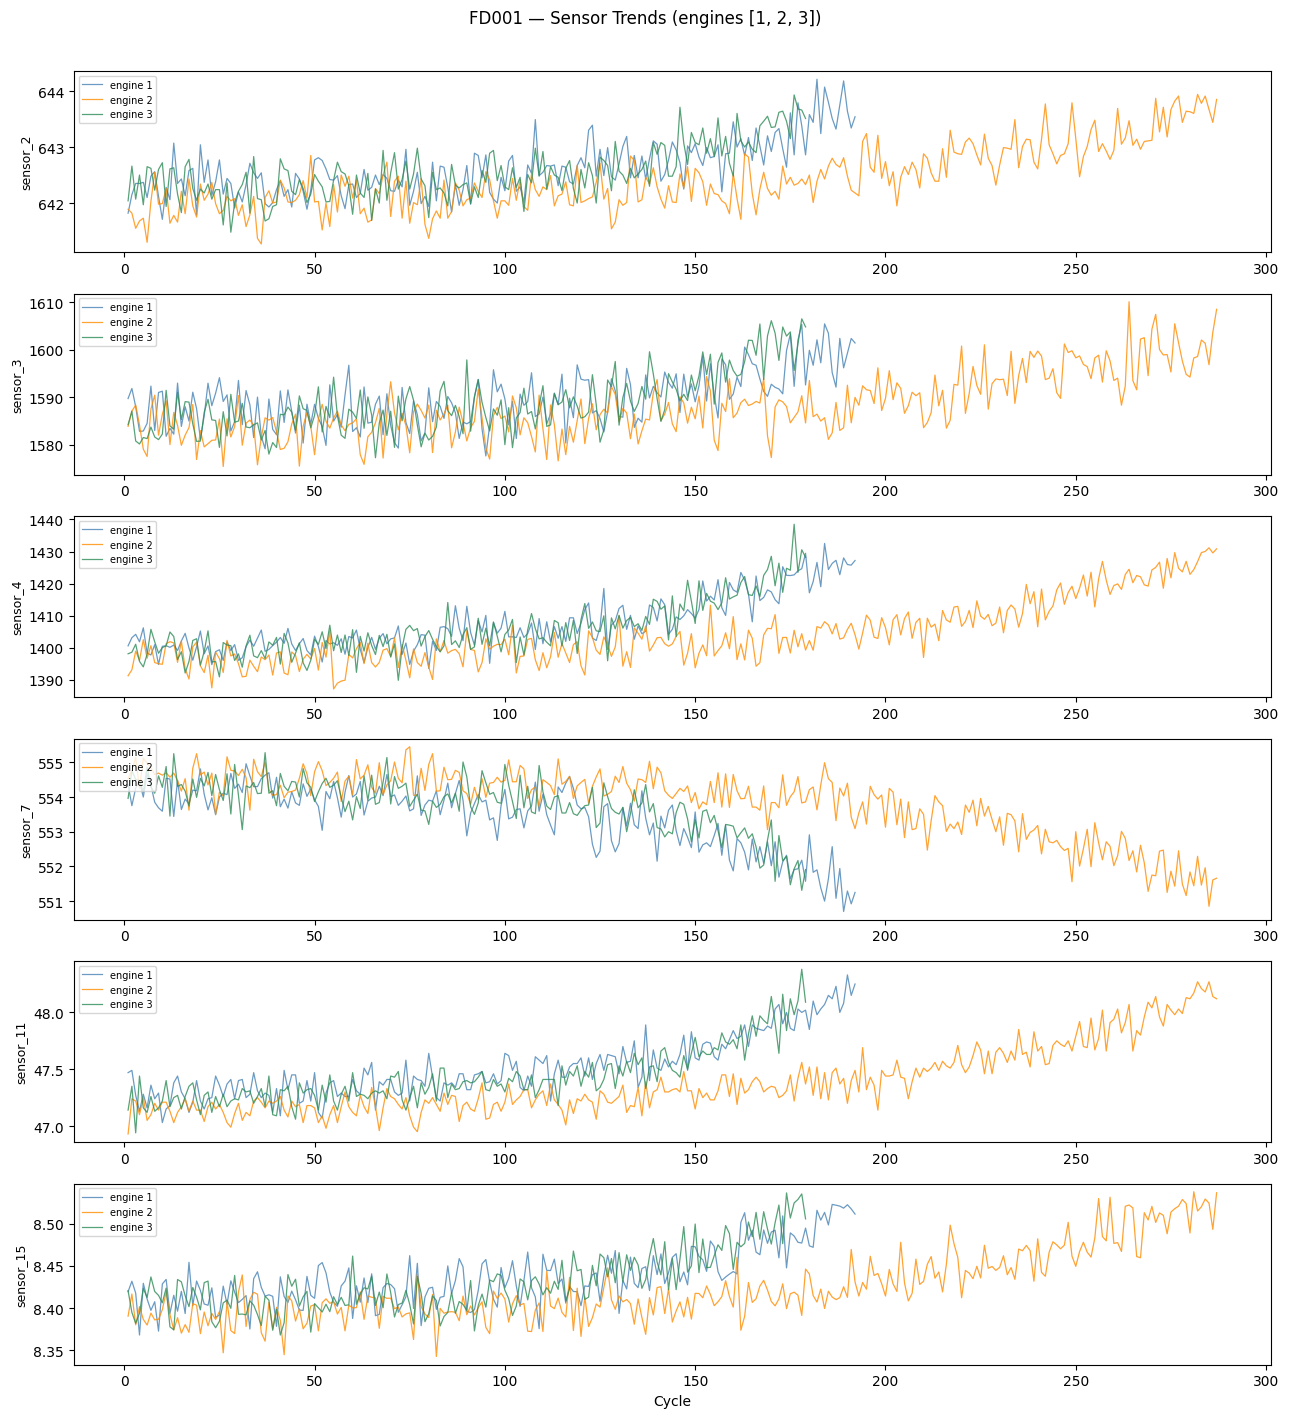

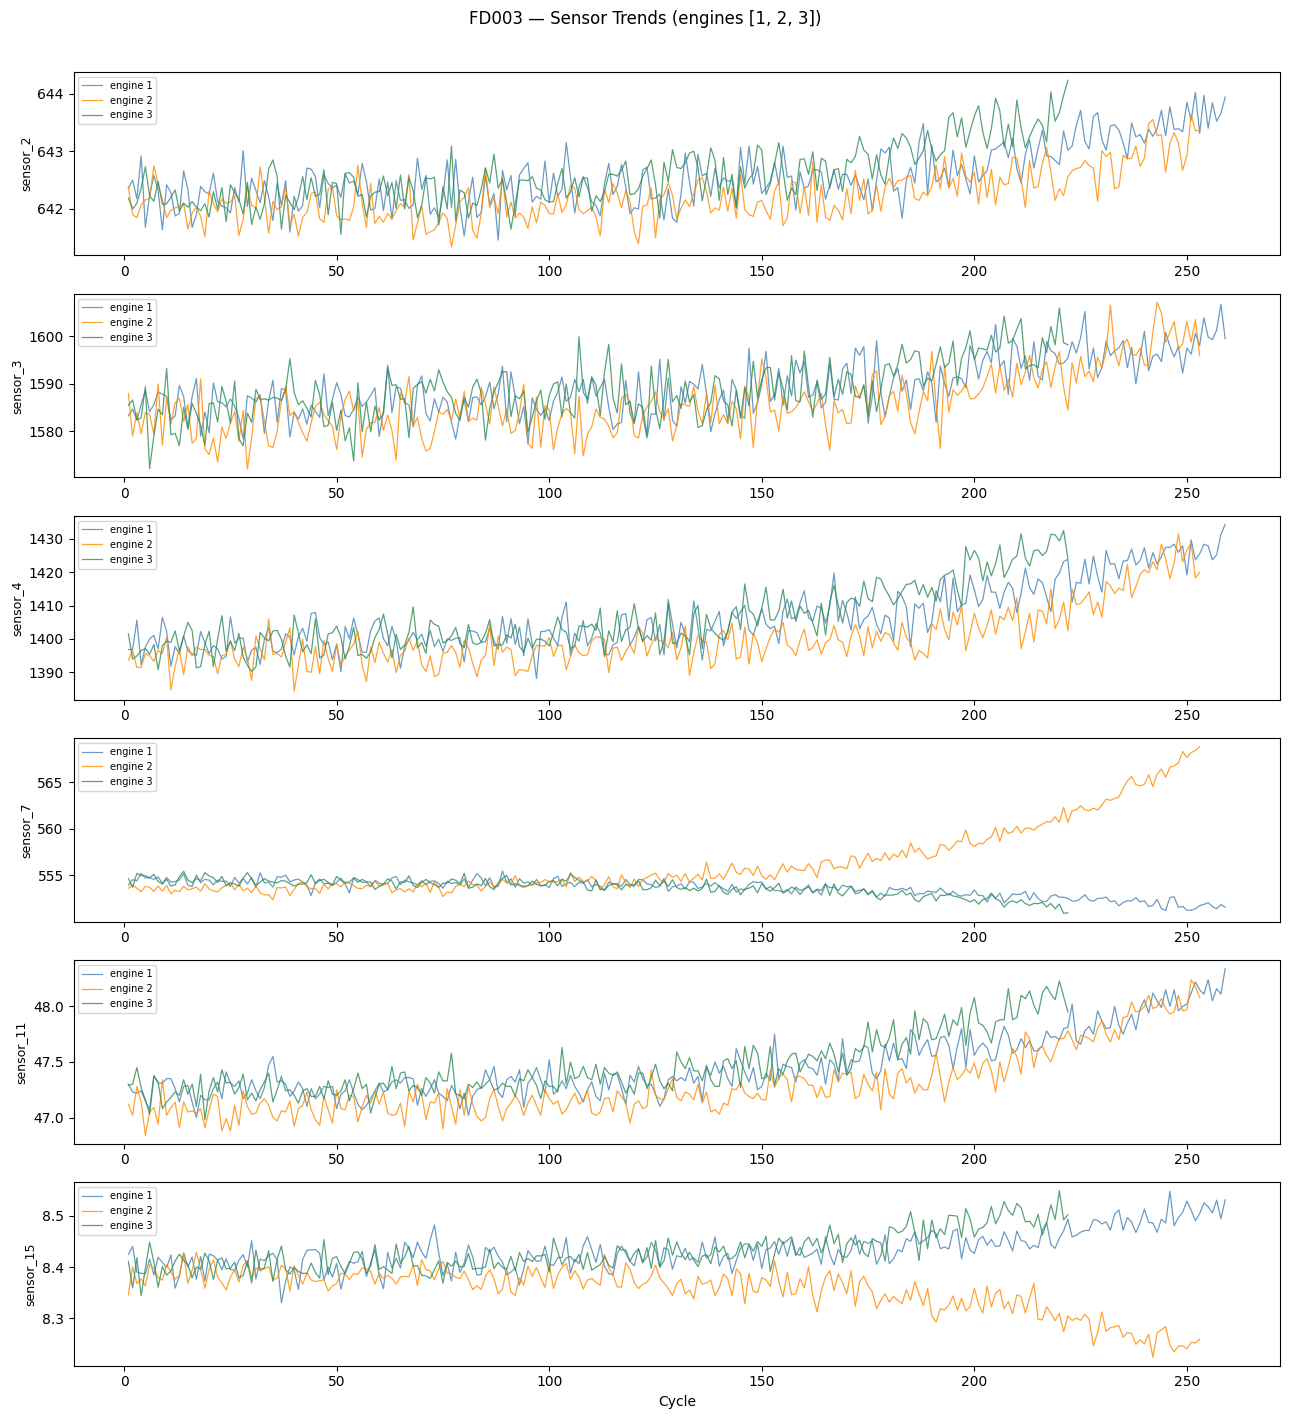

In [ ]:
# ── Sensor trends for 3 sample engines ────────────────────────────────────────
# Plotting a handful of informative sensors
PLOT_SENSORS = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
SAMPLE_UNITS = [1, 2, 3]

for ds in DATASETS:
    df = raw[ds]['train']
    fig, axes = plt.subplots(len(PLOT_SENSORS), 1, figsize=(13, 14), sharex=False)
    fig.suptitle(f'{ds} — Sensor Trends (engines {SAMPLE_UNITS})', fontsize=12, y=1.01)

    colors = ['steelblue', 'darkorange', 'seagreen']
    for ax, sensor in zip(axes, PLOT_SENSORS):
        for uid, col in zip(SAMPLE_UNITS, colors):
            sub = df[df['unit_nr'] == uid]
            ax.plot(sub['time_cycles'], sub[sensor], color=col, alpha=0.8,
                    linewidth=0.9, label=f'engine {uid}')
        ax.set_ylabel(sensor, fontsize=9)
        ax.legend(fontsize=7, loc='upper left')

    axes[-1].set_xlabel('Cycle')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'eda_sensor_trends_{ds}.png'), dpi=120)
    plt.show()

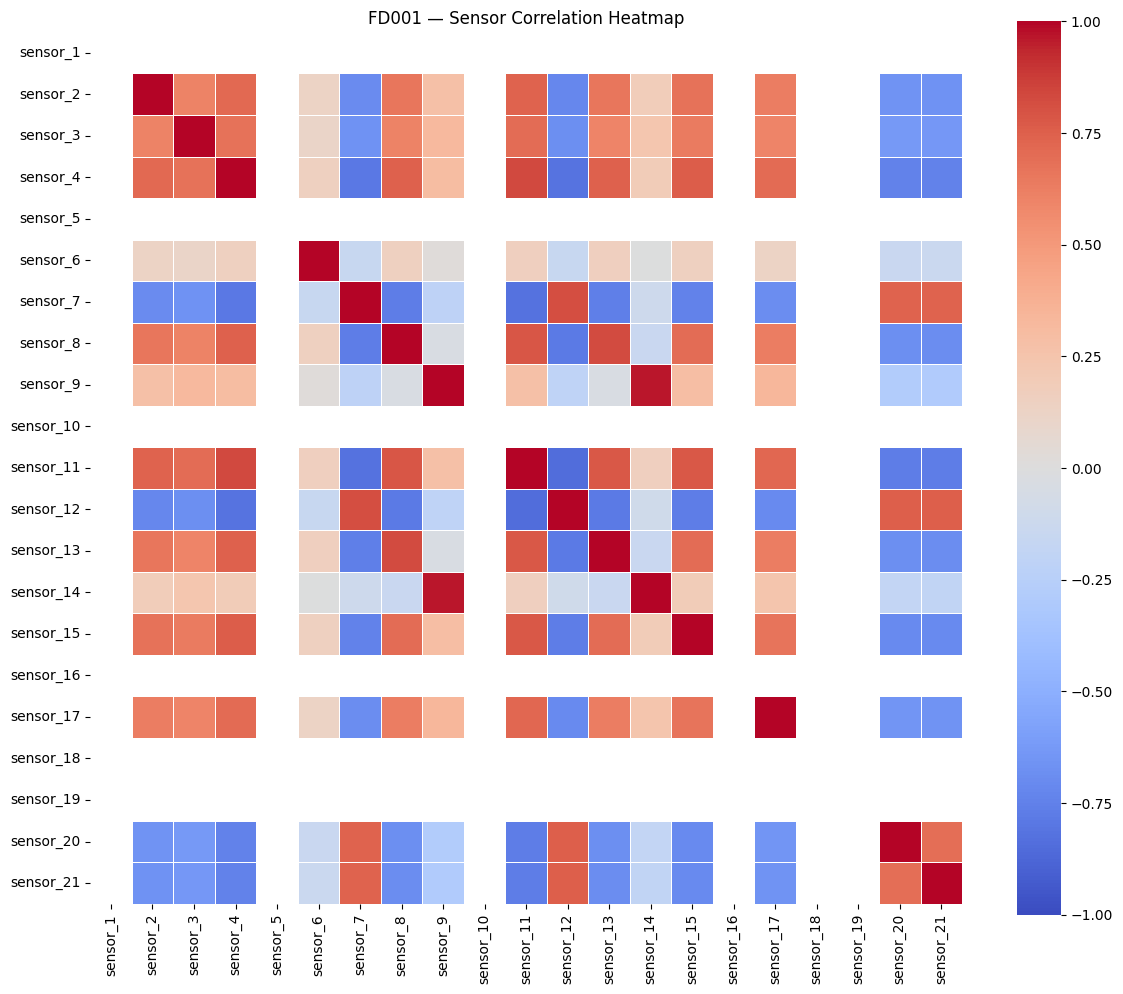

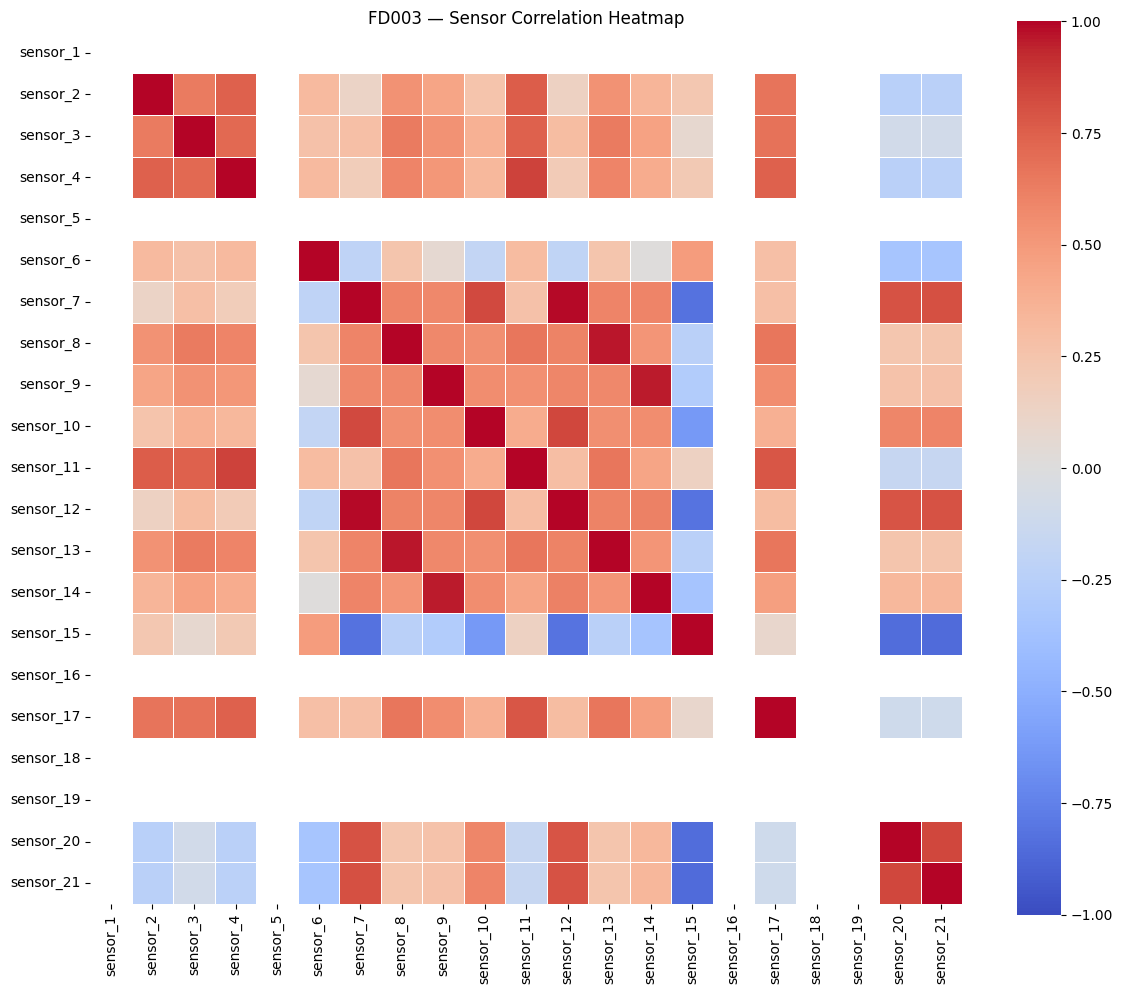

In [ ]:
# ── Sensor correlation heatmap ─────────────────────────────────────────────────
for ds in DATASETS:
    df = raw[ds]['train']
    corr = df[SENSOR_COLS].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr, ax=ax, cmap='coolwarm', center=0,
        vmin=-1, vmax=1, linewidths=0.4, linecolor='white',
        annot=False, square=True
    )
    ax.set_title(f'{ds} — Sensor Correlation Heatmap', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'eda_corr_heatmap_{ds}.png'), dpi=120)
    plt.show()

---
## Section 5 · Feature Selection

> **Initial feature set retained from C-MAPSS, with optional pruning of low-information sensors after exploratory analysis.**

Following the Sensors paper, the full 25-feature set is used as the starting point:  
`time_cycles` + 3 operational settings + 21 sensor readings.

Sensors that show near-zero variance across all engines carry no predictive signal and are removed to reduce noise and model complexity. A common variance threshold for C-MAPSS is `std < 0.001` after normalisation; here we apply it on the raw training data directly.

In [ ]:
# ── Identify and drop near-constant features ──────────────────────────────────
CANDIDATE_FEATURES = ['time_cycles'] + OP_SETTING_COLS + SENSOR_COLS
VARIANCE_THRESHOLD = 1e-3   # sensors whose std < threshold are dropped

selected_features = {}   # per-dataset final feature list

for ds in DATASETS:
    df = raw[ds]['train']
    stds = df[CANDIDATE_FEATURES].std()
    dropped = stds[stds < VARIANCE_THRESHOLD].index.tolist()
    kept    = [f for f in CANDIDATE_FEATURES if f not in dropped]

    selected_features[ds] = kept

    print(f'\n[{ds}]')
    print(f'  Dropped ({len(dropped)}) : {dropped}')
    print(f'  Retained ({len(kept)})   : {kept}')


[FD001]
  Dropped (8) : ['op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
  Retained (17)   : ['time_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

[FD003]
  Dropped (7) : ['op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
  Retained (18)   : ['time_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


---
## Section 6 · RUL Labelling for Training Set

We use a **piecewise linear** RUL target, as described in the Sensors paper.  
For each engine row:
$$\text{RUL}_{\text{label}} = \min\bigl(\text{max\_cycle} - \text{current\_cycle},\; R_{\max}\bigr)$$

where $R_{\max} = 125$ cycles. This cap reflects the assumption that an engine's degradation only becomes informative in the last 125 cycles of its life.

In [ ]:
RUL_CAP = 125

def add_rul_column(df: pd.DataFrame, cap: int = RUL_CAP) -> pd.DataFrame:
    """Add a piecewise-capped RUL column to a training dataframe."""
    df = df.copy()
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().rename('max_cycle')
    df = df.join(max_cycles, on='unit_nr')
    df['RUL'] = (df['max_cycle'] - df['time_cycles']).clip(upper=cap)
    df.drop(columns=['max_cycle'], inplace=True)
    return df


for ds in DATASETS:
    raw[ds]['train'] = add_rul_column(raw[ds]['train'])
    print(f'[{ds}] RUL range in training set: '
          f"{raw[ds]['train']['RUL'].min()} – {raw[ds]['train']['RUL'].max()}")

[FD001] RUL range in training set: 0 – 125
[FD003] RUL range in training set: 0 – 125


---
## Section 7 · Prepare Test Labels

The test files contain engine time-series truncated before failure.  
The separate `RUL_FDxxx.txt` file gives the **true RUL at the last observed cycle** for each test engine.  
We attach these ground-truth values so that evaluation metrics can be computed directly against the model's prediction on the final window of each test engine.

In [ ]:
for ds in DATASETS:
    df_test = raw[ds]['test'].copy()
    df_rul  = raw[ds]['rul'].copy()

    # Map RUL truth: row index in df_rul corresponds to engine (unit_nr sorted)
    df_rul.index = df_rul.index + 1   # unit_nr starts at 1
    df_rul.index.name = 'unit_nr'

    # Identify the last cycle row per engine in the test set
    last_cycle_idx = df_test.groupby('unit_nr')['time_cycles'].idxmax()
    df_last = df_test.loc[last_cycle_idx].copy().reset_index(drop=True)
    df_last['rul_true'] = df_rul['rul_true'].values
    # Cap test RUL at RUL_CAP as well (consistent with training target)
    df_last['rul_true'] = df_last['rul_true'].clip(upper=RUL_CAP)

    raw[ds]['test_last'] = df_last   # last-cycle rows with ground-truth RUL

    print(f'[{ds}] Test engines: {len(df_last)}, '
          f'RUL truth range: {df_last["rul_true"].min()} – {df_last["rul_true"].max()}')

[FD001] Test engines: 100, RUL truth range: 7 – 125
[FD003] Test engines: 100, RUL truth range: 6 – 125


---
## Section 8 · Normalisation / Scaling

A `StandardScaler` is fitted **exclusively on the training data** for each dataset and then applied to validation and test splits. This prevents any information leakage from future observations.  
The fitted scaler is saved to disk so that downstream notebooks can apply identical transformations without re-fitting.

In [ ]:
scalers = {}   # per-dataset scaler objects

for ds in DATASETS:
    feats = selected_features[ds]
    train_feats = raw[ds]['train'][feats].values

    scaler = StandardScaler()
    scaler.fit(train_feats)
    scalers[ds] = scaler

    # Persist scaler
    scaler_path = os.path.join(OUTPUT_DIR, f'scaler_{ds}.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)

    print(f'[{ds}] Scaler fitted on {train_feats.shape[0]} rows, '
          f'{train_feats.shape[1]} features. Saved → {scaler_path}')

[FD001] Scaler fitted on 20631 rows, 17 features. Saved → ./outputs/scaler_FD001.pkl
[FD003] Scaler fitted on 24720 rows, 18 features. Saved → ./outputs/scaler_FD003.pkl


---
## Section 9 · Sliding Window Sequence Creation

Following the Sensors paper:
- **Window size** $W = 50$ cycles
- **Stride** $s = 1$ (fully overlapping windows)

For each engine we slide a window of length 50 over its time-series. The target RUL assigned to each window is the RUL of the **last cycle** inside that window.  
Engines with fewer than 50 cycles produce no windows (they are skipped with a warning).

In [ ]:
WINDOW_SIZE = 50
STRIDE      = 1

def make_windows(df: pd.DataFrame,
                 feature_cols: list,
                 scaler: StandardScaler,
                 window_size: int = WINDOW_SIZE,
                 stride: int = STRIDE,
                 rul_col: str = 'RUL') -> tuple:
    """
    Build (X, y, unit_ids) arrays from a labelled dataframe.

    Returns
    -------
    X        : ndarray  shape (N, window_size, n_features)
    y        : ndarray  shape (N,)
    unit_ids : ndarray  shape (N,)  — engine id of each window's last cycle
    """
    X_list, y_list, uid_list = [], [], []

    for uid, grp in df.groupby('unit_nr'):
        grp = grp.sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)  # scale features
        rul   = grp[rul_col].values

        if len(feats) < window_size:
            print(f'  ⚠  Engine {uid}: only {len(feats)} cycles — skipped (< {window_size})')
            continue

        for start in range(0, len(feats) - window_size + 1, stride):
            end = start + window_size
            X_list.append(feats[start:end])   # shape (W, F)
            y_list.append(rul[end - 1])        # RUL at last cycle of window
            uid_list.append(uid)

    X = np.array(X_list, dtype=np.float32)       # (N, W, F)
    y = np.array(y_list, dtype=np.float32)        # (N,)
    ids = np.array(uid_list, dtype=np.int32)      # (N,)
    return X, y, ids


def make_test_windows(df_full: pd.DataFrame,
                      df_last: pd.DataFrame,
                      feature_cols: list,
                      scaler: StandardScaler,
                      window_size: int = WINDOW_SIZE) -> tuple:
    """
    For the test set, extract ONE window per engine ending at its last observed
    cycle, with the corresponding ground-truth RUL.
    """
    X_list, y_list, uid_list = [], [], []

    for _, row in df_last.iterrows():
        uid = int(row['unit_nr'])
        grp = df_full[df_full['unit_nr'] == uid].sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)

        if len(feats) < window_size:
            print(f'  ⚠  Test engine {uid}: only {len(feats)} cycles — skipped.')
            continue

        # Take the last `window_size` cycles
        X_list.append(feats[-window_size:])     # (W, F)
        y_list.append(row['rul_true'])
        uid_list.append(uid)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    ids = np.array(uid_list, dtype=np.int32)
    return X, y, ids


print('Sliding-window functions defined.')

Sliding-window functions defined.


---
## Section 10 · Train / Validation Split

The split is performed **by engine id** before windowing, preventing any time-series from the same engine from appearing in both the training and validation sets (which would constitute temporal data leakage).

We use a **70 / 15 / 15** split (train / validation / test-hold-out) rather than the classic 80 / 20, providing a dedicated held-out set for hyper-parameter search during model development while keeping the official test set untouched for final evaluation. Engine ids are shuffled before splitting to avoid any ordering bias.

In [ ]:
# ── 70 / 15 / 15 split by engine id ──────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# Remaining 0.15 → internal hold-out (separate from official test set)

datasets_processed = {}

for ds in DATASETS:
    feats  = selected_features[ds]
    scaler = scalers[ds]
    df_tr  = raw[ds]['train']     # labelled training data
    df_te  = raw[ds]['test']      # official test data (no RUL col yet)
    df_last = raw[ds]['test_last']

    # ── Engine-level split ────────────────────────────────────────────────────
    engine_ids = df_tr['unit_nr'].unique()
    np.random.shuffle(engine_ids)  # in-place shuffle

    n_total = len(engine_ids)
    n_train = int(np.floor(TRAIN_FRAC * n_total))
    n_val   = int(np.floor(VAL_FRAC   * n_total))
    # remainder → internal hold-out

    train_ids  = engine_ids[:n_train]
    val_ids    = engine_ids[n_train : n_train + n_val]
    hold_ids   = engine_ids[n_train + n_val :]

    df_train_split = df_tr[df_tr['unit_nr'].isin(train_ids)]
    df_val_split   = df_tr[df_tr['unit_nr'].isin(val_ids)]
    df_hold_split  = df_tr[df_tr['unit_nr'].isin(hold_ids)]

    print(f'\n[{ds}] Engine split — '
          f'train: {len(train_ids)} | val: {len(val_ids)} | hold-out: {len(hold_ids)}')

    # ── Build windows ─────────────────────────────────────────────────────────
    X_train, y_train, ids_train = make_windows(df_train_split, feats, scaler)
    X_val,   y_val,   ids_val   = make_windows(df_val_split,   feats, scaler)
    X_hold,  y_hold,  ids_hold  = make_windows(df_hold_split,  feats, scaler)
    X_test,  y_test,  ids_test  = make_test_windows(df_te, df_last, feats, scaler)

    datasets_processed[ds] = {
        'X_train': X_train, 'y_train': y_train, 'ids_train': ids_train,
        'X_val'  : X_val,   'y_val'  : y_val,   'ids_val'  : ids_val,
        'X_hold' : X_hold,  'y_hold' : y_hold,  'ids_hold' : ids_hold,
        'X_test' : X_test,  'y_test' : y_test,  'ids_test' : ids_test,
        'features': feats
    }

    print(f'  X_train : {X_train.shape}  y_train : {y_train.shape}')
    print(f'  X_val   : {X_val.shape}   y_val   : {y_val.shape}')
    print(f'  X_hold  : {X_hold.shape}  y_hold  : {y_hold.shape}')
    print(f'  X_test  : {X_test.shape}  y_test  : {y_test.shape}')


[FD001] Engine split — train: 70 | val: 15 | hold-out: 15
  ⚠  Test engine 1: only 31 cycles — skipped.
  ⚠  Test engine 2: only 49 cycles — skipped.
  ⚠  Test engine 14: only 46 cycles — skipped.
  ⚠  Test engine 22: only 39 cycles — skipped.
  ⚠  Test engine 25: only 48 cycles — skipped.
  ⚠  Test engine 39: only 37 cycles — skipped.
  ⚠  Test engine 85: only 34 cycles — skipped.
  X_train : (10886, 50, 17)  y_train : (10886,)
  X_val   : (2435, 50, 17)   y_val   : (2435,)
  X_hold  : (2410, 50, 17)  y_hold  : (2410,)
  X_test  : (93, 50, 17)  y_test  : (93,)

[FD003] Engine split — train: 70 | val: 15 | hold-out: 15
  ⚠  Test engine 37: only 47 cycles — skipped.
  ⚠  Test engine 52: only 38 cycles — skipped.
  ⚠  Test engine 88: only 41 cycles — skipped.
  X_train : (13307, 50, 18)  y_train : (13307,)
  X_val   : (2992, 50, 18)   y_val   : (2992,)
  X_hold  : (3521, 50, 18)  y_hold  : (3521,)
  X_test  : (97, 50, 18)  y_test  : (97,)


---
## Section 11 · Save Processed Artefacts

In [ ]:
# ── Save .npz arrays ──────────────────────────────────────────────────────────
for ds in DATASETS:
    d = datasets_processed[ds]
    out_path = os.path.join(OUTPUT_DIR, f'{ds}_processed.npz')

    np.savez_compressed(
        out_path,
        X_train=d['X_train'], y_train=d['y_train'], ids_train=d['ids_train'],
        X_val  =d['X_val'],   y_val  =d['y_val'],   ids_val  =d['ids_val'],
        X_hold =d['X_hold'],  y_hold =d['y_hold'],  ids_hold =d['ids_hold'],
        X_test =d['X_test'],  y_test =d['y_test'],  ids_test =d['ids_test'],
    )
    print(f'[{ds}] Arrays saved → {out_path}')


# ── Save feature lists ────────────────────────────────────────────────────────
features_path = os.path.join(OUTPUT_DIR, 'selected_features.json')
with open(features_path, 'w') as f:
    json.dump(selected_features, f, indent=2)
print(f'Feature lists saved → {features_path}')


# ── Save scalers ──────────────────────────────────────────────────────────────
# (already saved in Section 8 — confirm)
for ds in DATASETS:
    p = os.path.join(OUTPUT_DIR, f'scaler_{ds}.pkl')
    print(f'[{ds}] Scaler confirmed at {p} (exists: {os.path.exists(p)})')


# ── Save metadata ─────────────────────────────────────────────────────────────
metadata = {
    'window_size' : WINDOW_SIZE,
    'stride'      : STRIDE,
    'rul_cap'     : RUL_CAP,
    'train_frac'  : TRAIN_FRAC,
    'val_frac'    : VAL_FRAC,
    'random_seed' : RANDOM_SEED,
    'scaler_type' : 'StandardScaler',
    'datasets'    : DATASETS,
}
meta_path = os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved → {meta_path}')

[FD001] Arrays saved → ./outputs/FD001_processed.npz
[FD003] Arrays saved → ./outputs/FD003_processed.npz
Feature lists saved → ./outputs/selected_features.json
[FD001] Scaler confirmed at ./outputs/scaler_FD001.pkl (exists: True)
[FD003] Scaler confirmed at ./outputs/scaler_FD003.pkl (exists: True)
Metadata saved → ./outputs/preprocessing_metadata.json


---
## Section 12 · Final Sanity Checks

In [ ]:
# ── Array shapes ──────────────────────────────────────────────────────────────
print('=' * 60)
for ds in DATASETS:
    d = datasets_processed[ds]
    print(f'\n[{ds}]')
    for split in ('train', 'val', 'hold', 'test'):
        X = d[f'X_{split}']
        y = d[f'y_{split}']
        print(f'  {split:>5s}  X: {str(X.shape):>22}   y: {str(y.shape):>10}  '
              f'RUL [{y.min():.1f}, {y.max():.1f}]')
print('=' * 60)


[FD001]
  train  X:        (10886, 50, 17)   y:   (10886,)  RUL [0.0, 125.0]
    val  X:         (2435, 50, 17)   y:    (2435,)  RUL [0.0, 125.0]
   hold  X:         (2410, 50, 17)   y:    (2410,)  RUL [0.0, 125.0]
   test  X:           (93, 50, 17)   y:      (93,)  RUL [7.0, 125.0]

[FD003]
  train  X:        (13307, 50, 18)   y:   (13307,)  RUL [0.0, 125.0]
    val  X:         (2992, 50, 18)   y:    (2992,)  RUL [0.0, 125.0]
   hold  X:         (3521, 50, 18)   y:    (3521,)  RUL [0.0, 125.0]
   test  X:           (97, 50, 18)   y:      (97,)  RUL [6.0, 125.0]


In [ ]:
# ── Sample sequence and target ────────────────────────────────────────────────
ds_check = 'FD001'
d        = datasets_processed[ds_check]
feats    = d['features']

idx = 0   # first window
print(f'[{ds_check}] Sample window index : {idx}')
print(f'  Shape : {d["X_train"][idx].shape}   (window_size × n_features)')
print(f'  RUL target : {d["y_train"][idx]:.1f} cycles')
print(f'  Engine id  : {d["ids_train"][idx]}')
print(f'\n  First 5 time-steps (first 5 features):')
print(pd.DataFrame(d['X_train'][idx][:5, :5],
                   columns=feats[:5]).to_string(index=False))

[FD001] Sample window index : 0
  Shape : (50, 17)   (window_size × n_features)
  RUL target : 125.0 cycles
  Engine id  : 1

  First 5 time-steps (first 5 features):
 time_cycles  op_setting_1  sensor_2  sensor_3  sensor_4
   -1.565170     -0.315980 -1.721725 -0.134255 -0.925936
   -1.550652      0.872722 -1.061780  0.211528 -0.643726
   -1.536134     -1.961874 -0.661813 -0.413166 -0.525953
   -1.521616      0.324090 -0.661813 -1.261314 -0.784831
   -1.507098     -0.864611 -0.621816 -1.251528 -0.301518


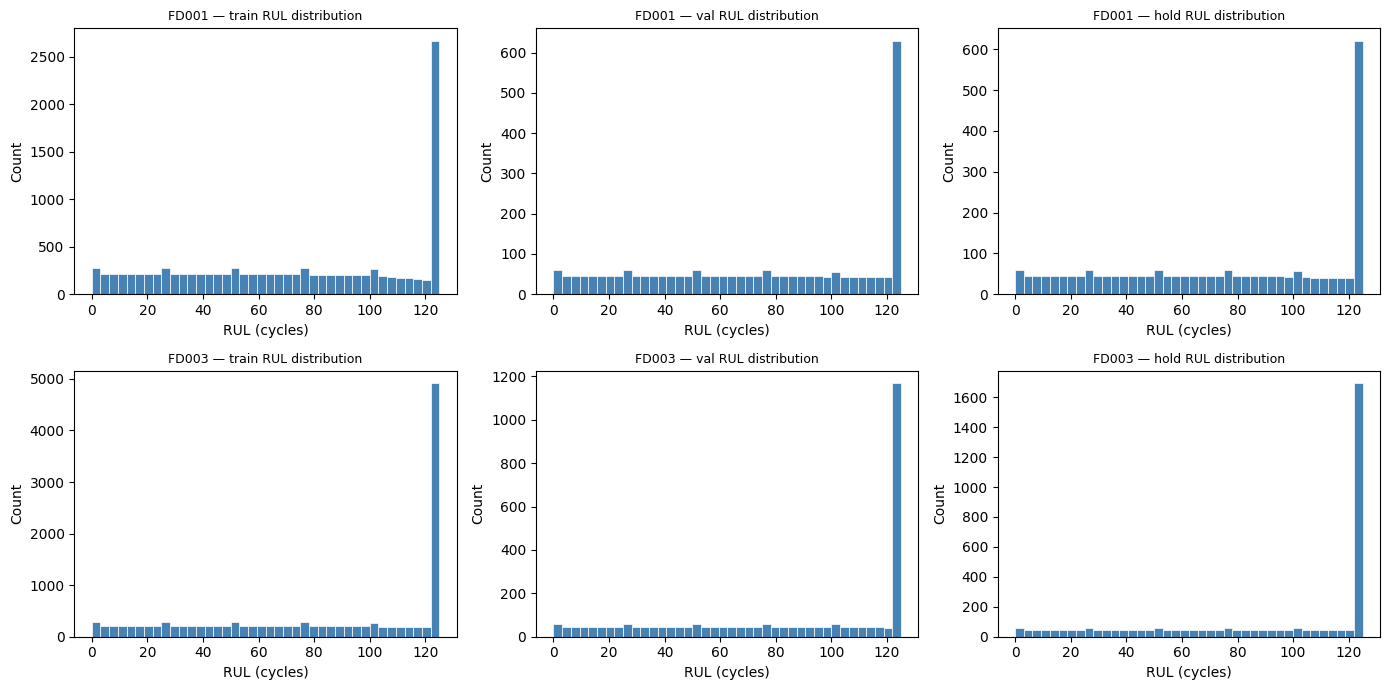

In [ ]:
# ── RUL distribution across splits ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for row_idx, ds in enumerate(DATASETS):
    d = datasets_processed[ds]
    for col_idx, split in enumerate(['train', 'val', 'hold']):
        ax = axes[row_idx, col_idx]
        ax.hist(d[f'y_{split}'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
        ax.set_title(f'{ds} — {split} RUL distribution', fontsize=9)
        ax.set_xlabel('RUL (cycles)')
        ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sanity_rul_distributions.png'), dpi=120)
plt.show()

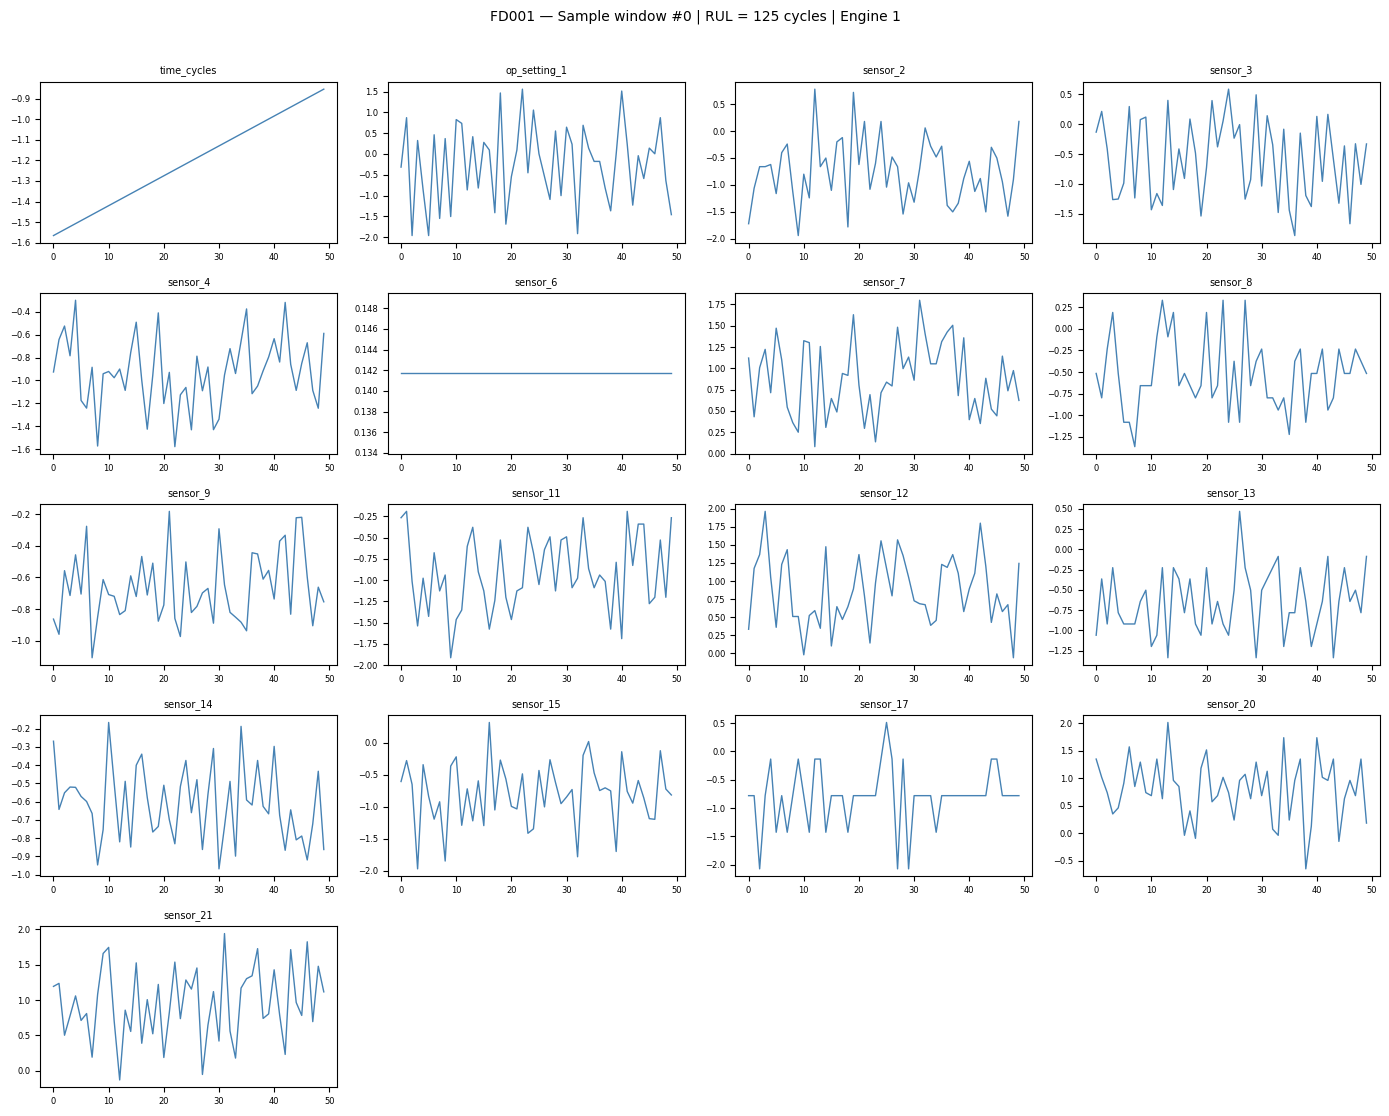


✅  Preprocessing complete. All artefacts written to: /content/outputs


In [ ]:
# ── Plot one sample sequence (all features) ───────────────────────────────────
ds_check = 'FD001'
d        = datasets_processed[ds_check]
feats    = d['features']
seq      = d['X_train'][0]   # shape (50, n_features)

n_feats = seq.shape[1]
n_cols  = 4
n_rows  = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.2))
axes_flat = axes.flatten()

for i, feat in enumerate(feats):
    axes_flat[i].plot(seq[:, i], color='steelblue', linewidth=1)
    axes_flat[i].set_title(feat, fontsize=7)
    axes_flat[i].tick_params(labelsize=6)

# Hide unused subplots
for j in range(len(feats), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'{ds_check} — Sample window #{0} | '
             f'RUL = {d["y_train"][0]:.0f} cycles | '
             f'Engine {d["ids_train"][0]}',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sanity_sample_sequence.png'), dpi=120)
plt.show()

print('\n✅  Preprocessing complete. All artefacts written to:', os.path.abspath(OUTPUT_DIR))

In [ ]:
import shutil
from google.colab import files

# Define the name for the zipped archive
zip_filename = 'outputs.zip'

# Create a zip file of the /outputs directory
shutil.make_archive('outputs', 'zip', OUTPUT_DIR)

print(f"Archive created: {zip_filename}")

# Download the single zip file
files.download(zip_filename)

Archive created: all_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The code above lists all files in the `outputs` directory. If you wish to download them, uncomment the `files.download(file_path)` line and run the cell. This will initiate a download for each file to your local machine.